In [213]:
#pip install catboost

In [214]:
#pip install category_encoders

In [215]:
#pip install optuna

In [216]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                      cross_val_predict, train_test_split)
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from category_encoders import TargetEncoder, LeaveOneOutEncoder
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import optuna
import shap
import joblib
import warnings

In [217]:
train_df = pd.read_csv("/content/train_set_spaceship_titanic.csv")
test_df = pd.read_csv("/content/test_set_spaceship_titanic.csv")

In [218]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [219]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (8693, 14)
Test shape: (4277, 13)


In [220]:
test_df['Transported'] = np.nan
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
print(f"Combined shape: {df.shape}")

Combined shape: (12970, 14)


In [221]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1.0


In [222]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,288
CryoSleep,310
Cabin,299
Destination,274
Age,270
VIP,296
RoomService,263
FoodCourt,289
ShoppingMall,306


BASE EXTRACTION

In [223]:
# PassengerId
df['GroupID'] = df['PassengerId'].str.split('_').str[0]
df['GroupPosition'] = df['PassengerId'].str.split('_').str[1].astype(int)

In [224]:
# Name
df['FirstName'] = df['Name'].str.split(' ').str[0]
df['LastName'] = df['Name'].str.split(' ').str[-1]

In [225]:
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')

In [226]:
# Group & Family sizes
df['GroupSize'] = df.groupby('GroupID')['GroupID'].transform('count')
df['FamilySize'] = df.groupby('LastName')['LastName'].transform('count')

print(f"GroupID extracted: {df['GroupID'].nunique()} unique groups")
print(f"Deck values: {df['Deck'].unique()}")

GroupID extracted: 9280 unique groups
Deck values: ['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']


FAMILY VS NON-FAMILY DETECTION

In [227]:
df['GroupLastNameUnique'] = df.groupby('GroupID')['LastName'].transform('nunique')
df['GroupCabinUnique'] = df.groupby('GroupID')['Cabin'].transform('nunique')
df['GroupPlanetUnique'] = df.groupby('GroupID')['HomePlanet'].transform('nunique')
df['GroupAgeRange'] = df.groupby('GroupID')['Age'].transform(
    lambda x: x.max() - x.min()
).fillna(0)

In [228]:
df['SameLastName'] = (df['GroupLastNameUnique'] == 1).astype(int)
df['SharesCabin'] = (df['GroupCabinUnique'] == 1).astype(int)
df['SameHomePlanet'] = (df['GroupPlanetUnique'] == 1).astype(int)
df['WideAgeRange'] = (df['GroupAgeRange'] > 15).astype(int)

In [229]:
df['FamilyScore'] = (
    df['SameLastName'] * 0.5 +
    df['SharesCabin'] * 0.2 +
    df['SameHomePlanet'] * 0.2 +
    df['WideAgeRange'] * 0.1
)
df['IsFamilyGroup'] = (df['FamilyScore'] >= 0.7).astype(int)

print(f"Family groups: {df[df['IsFamilyGroup']==1]['GroupID'].nunique()}")
print(f"Non-family groups: {df[df['IsFamilyGroup']==0]['GroupID'].nunique()}")

Family groups: 8754
Non-family groups: 526


MISSING INDICATOR FLAGS

In [230]:
null_flag_cols = ['Age', 'HomePlanet', 'Destination', 'CryoSleep', 'Deck', 'Side', 'VIP']
for col in null_flag_cols:
  df[f'{col}_WasNull'] = df[col].isna().astype(int)
  print(f"{col}_WasNull: {df[f'{col}_WasNull'].sum()} flagged")



Age_WasNull: 270 flagged
HomePlanet_WasNull: 288 flagged
Destination_WasNull: 274 flagged
CryoSleep_WasNull: 310 flagged
Deck_WasNull: 299 flagged
Side_WasNull: 299 flagged
VIP_WasNull: 296 flagged


DOMAIN LOGIC FILLS

In [231]:
# Spending -> 0 for CryoSleep = True
df['TotalSpending'] = df[spend_cols].sum(axis=1)
df.loc[df['CryoSleep'] == True, spend_cols] = 0

# Spending > 0 -> CryoSleep = False
df.loc[df['TotalSpending'] > 0, 'CryoSleep'] = False

# Recompute TotalSpending after domain fills
df['TotalSpending'] = df[spend_cols].sum(axis=1)


In [232]:
# Flagging remain NA values in each spending columns and imputing them with 0
for col in spend_cols:
  df[f'{col}_WasNull'] = df[col].isna().astype(int)
  df[col] = df[col].fillna(0)

In [233]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,288
CryoSleep,136
Cabin,299
Destination,274
Age,270
VIP,296
RoomService,0
FoodCourt,0
ShoppingMall,0


In [234]:
df['TotalSpending'] = df[spend_cols].sum(axis=1)

print(f"CryoSleep violation fixed")

CryoSleep violation fixed


GROUP-BASED IMPUTATION

In [235]:
family_mask = df['IsFamilyGroup'] == 1
non_family_mask = df['IsFamilyGroup'] == 0

for mask in [family_mask, non_family_mask]:
  df.loc[mask, 'HomePlanet'] = df[mask].groupby('GroupID')['HomePlanet'].transform(
      lambda x: x.ffill().bfill()
  )

df['Destination'] = df.groupby('GroupID')['Destination'].transform(
    lambda x: x.ffill().bfill()
)

df.loc[family_mask, 'CryoSleep'] = df[family_mask].groupby('GroupID').transform(
    lambda x: x.ffill().bfill()
)

df.loc[non_family_mask, 'CryoSleep'] = df[non_family_mask].groupby('GroupID')['CryoSleep'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False)
)

group_deck_nunique = df.groupby('GroupID')['Deck'].transform('nunique').fillna(1)
df['CabinConflict'] = (group_deck_nunique > 1).astype(int)
clean_mask = (group_deck_nunique == 1)

for col in ['Deck', 'Side']:
  df.loc[clean_mask, col] = df[clean_mask].groupby('GroupID')[col].transform(
      lambda x: x.ffill().bfill()
  )

for mask in [family_mask, non_family_mask]:
  df.loc[mask, 'Age'] = df[mask].groupby('GroupID')['Age'].transform(
      lambda x: x.fillna(x.median())
  )


/tmp/ipykernel_4710/3552866512.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.ffill().bfill()
/tmp/ipykernel_4710/3552866512.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.ffill().bfill()
/tmp/ipykernel_4710/3552866512.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.ffill().bfill()
/tmp/i

In [236]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,157
CryoSleep,50
Cabin,299
Destination,154
Age,144
VIP,296
RoomService,0
FoodCourt,0
ShoppingMall,0


REMAINING STATISTICAL FALLBACK IMPUTATION

In [237]:
# Age - subgroup median then global
df['Age'] = df.groupby(['HomePlanet', 'Destination'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

df['Age'] = df['Age'].fillna(df['Age'].median())

# HomePanet
df['HomePlanet'] = df.groupby(['Destination', 'Deck'])['HomePlanet'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])

# Destination
df['Destination'] = df.groupby(['HomePlanet', 'Deck'])['Destination'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])

# Deck, Side
for col in ['Deck', 'Side']:
  df[col] = df.groupby(['HomePlanet', 'Destination'])[col].transform(
      lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
  )
  df[col] = df[col].fillna(df[col].mode()[0])

# CabinNum
df['CabinNum'] = df.groupby('Deck')['CabinNum'].transform(
    lambda x: x.fillna(x.median())
)
df['CabinNum'] = df['CabinNum'].fillna(df['CabinNum'].median())

# CryoSleep remaining
df.loc[df['TotalSpending'] > 0, 'CryoSleep'] = False
df['CryoSleep'] = df.groupby('HomePlanet')['CryoSleep'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False)
)
df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(bool)

# VIP
df['VIP'] = df.groupby(['HomePlanet', 'Destination'])['VIP'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False)
)
df['VIP'] = df['VIP'].fillna(False).astype(bool)



/tmp/ipykernel_4710/125977170.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
/tmp/ipykernel_4710/125977170.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False)


In [238]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,299
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


FEATURE ENGINEERING

In [239]:
df['LuxurySpending'] = df['Spa'] + df['VRDeck']
df['BasicSpending'] = df['FoodCourt'] + df['RoomService'] + df['ShoppingMall']
df['LuxuryRatio'] = df['LuxurySpending'] / (df['TotalSpending'] + 1)
df['BasicRatio'] = df['BasicSpending'] / (df['TotalSpending'] + 1)
df['SpendConcentration'] = df[spend_cols].max(axis=1) / (df['TotalSpending'] + 1)
df['SpendEntropy'] = df[spend_cols].apply(lambda x: entropy(x + 1), axis=1)
df['SpendStd'] = df[spend_cols].std(axis=1)
df['NumServiceUsed'] = (df[spend_cols] > 0).sum(axis=1)
df['IsZeroSpender'] = (df['TotalSpending'] == 0).astype(int)

df['HasRoomService'] = (df['RoomService'] > 0).astype(int)
df['HasSpa'] = (df['Spa'] > 0).astype(int)
df['HasVRDeck'] = (df['VRDeck'] > 0).astype(int)
df['HasFoodCourt'] = (df['FoodCourt'] > 0).astype(int)
df['HasShoppingMall'] = (df['ShoppingMall'] > 0).astype(int)

# Group Aggregations
df['GroupAvgSpend'] = df.groupby('GroupID')['TotalSpending'].transform('mean')
df['GroupStdSpend'] = df.groupby('GroupID')['TotalSpending'].transform('std').fillna(0)

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 17, 25, 35, 50, 65, 200],
    labels=[0, 1, 2, 3, 4, 5, 6]
).astype(float)
df['GroupAvgAge'] = df.groupby('GroupID')['Age'].transform('mean')
df['GroupStdAge'] = df.groupby('GroupID')['Age'].transform('std').fillna(0)
df['AgeGroupAvgSpend'] = df.groupby('AgeGroup')['TotalSpending'].transform('mean')
df['AgeGroupStdSpend'] = df.groupby('AgeGroup')['TotalSpending'].transform('std').fillna(0)

df['PlanetAvgSpend'] = df.groupby('HomePlanet')['TotalSpending'].transform('mean')
df['PlanetStdSpend'] = df.groupby('HomePlanet')['TotalSpending'].transform('std').fillna(0)

df['DestAvgSpend'] = df.groupby('Destination')['TotalSpending'].transform('mean')
df['DeckAvgSpend'] = df.groupby('Deck')['TotalSpending'].transform('mean')

# Relative Spend Features
df['SpendVsPlanet'] = df['TotalSpending'] - df['PlanetAvgSpend']
df['SpendVsDest'] = df['TotalSpending'] - df['DestAvgSpend']
df['SpendVsGroup'] = df['TotalSpending'] - df['GroupAvgSpend']
df['SpendPerPerson'] = df['TotalSpending'] / (df['GroupSize'] + 1)
df['SpendZScore'] = df['SpendVsPlanet'] / (df['PlanetStdSpend'] + 1e-9)
df['SpendRankInGroup'] = df.groupby('GroupID')['TotalSpending'].rank(pct=True)
df['SpendAbovePlanet'] = (df['TotalSpending'] > df['PlanetAvgSpend']).astype(int)
df['SpendAboveGroup'] = (df['TotalSpending'] > df['GroupAvgSpend']).astype(int)

# CryoSleep Features
df['CryoSleep_int'] = df['CryoSleep'].astype(int)
df['CryoSleep_Violated'] = ((df['CryoSleep'] == True) & (df['TotalSpending'] > 0)).astype(int)
df['CanSpend'] = (~df['CryoSleep']).astype(int)
df['AgeCryo'] = df['Age'] * df['CryoSleep_int']
df['LuxuryCryo'] = df['LuxurySpending'] * df['CryoSleep_int']
df['CryoAndZeroSpend'] = (
    (df['CryoSleep_int'] == 1) & (df['IsZeroSpender'] == 1)
    ).astype(int)
df['NonCryoZeroSpend'] = (
    (df['CryoSleep_int'] == 0) & (df['IsZeroSpender'] == 1)
    ).astype(int)
df['GroupCryoRate'] = df.groupby('GroupID')['CryoSleep_int'].transform('mean')

# Age Features
df['IsChild'] = (df['Age'] < 13).astype(int)
df['IsElderly'] = (df['Age'] > 65).astype(int)
df['ChildSpending'] = df['IsChild'] * df['TotalSpending']
df['ElderlySpending'] = df['IsElderly'] * df['TotalSpending']

# Group / Family Features
df['IsSolo'] = (df['GroupSize'] == 1).astype(int)
df['IsGroupPosition'] = (df['GroupPosition'] == 1).astype(int)
df['SameCabinAsGroup'] = df['SharesCabin']
df['FamilyGroupSpan'] = df.groupby('LastName')['GroupID'].transform('nunique')
df['UniqueFamilyName'] = (df['FamilySize'] == 1).astype(int)

# Cabin Features
df['DeckSide'] = df['Deck'].astype(str) + '_' + df['Side'].astype(str)
df['CabinNumNormalized'] = df.groupby('Deck')['CabinNum'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-5)
)

# VIP Features
df['VIP_int'] = df['VIP'].astype(int)
df['VIP_LuxurySpend'] = df['VIP_int'] * df['LuxurySpending']
df['HighSpendNonVIP'] = (
    (df['VIP'] == False) &
    (df['TotalSpending'] > df['TotalSpending'].quantile(0.9))
).astype(int)

# Interaction Features
df['SoloHighSpend'] = df['IsSolo'] * df['TotalSpending']
df['LuxuryToBasic'] = df['LuxurySpending'] / (df['BasicSpending'] + 1)
df['FamilySizeSpend'] = df['FamilySize'] * df['TotalSpending']
for col in spend_cols:
    df[f'{col}_ratio'] = df[col] / (df['TotalSpending'] + 1)



/tmp/ipykernel_4710/1977187535.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['HighSpendNonVIP'] = (
/tmp/ipykernel_4710/1977187535.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SoloHighSpend'] = df['IsSolo'] * df['TotalSpending']
/tmp/ipykernel_4710/1977187535.py:90: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame

SPLIT BACK TO TRAIN / TEST

In [240]:
print("\n── Step 9: Split Back ──")

train_df = df[df['Transported'].notna()].copy()
test_df  = df[df['Transported'].isna()].copy()

# Drop identifier and raw columns
# GroupID and LastName dropped here — no LOO so not needed
drop_cols = [
    'PassengerId', 'Name', 'Cabin',
    'FirstName', 'LastName', 'GroupID',  # identifiers
    'CryoSleep', 'VIP',                  # replaced by _int versions
    'Transported'
]

feature_cols = [c for c in train_df.columns if c not in drop_cols]

X      = train_df[feature_cols].copy()
y      = train_df['Transported'].astype(int)
X_test = test_df[feature_cols].copy()

print(f"  X shape:      {X.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  Features:     {X.shape[1]}")


# ============================================================
# STEP 10 — TRAIN / VAL SPLIT
# ============================================================
print("\n── Step 10: Train/Val Split ──")

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")



── Step 9: Split Back ──
  X shape:      (8693, 101)
  X_test shape: (4277, 101)
  Features:     101

── Step 10: Train/Val Split ──
  X_train: (6954, 101)
  X_val:   (1739, 101)


TARGET ENCODING

In [241]:
print("\n── Step 11: Target Encoding ──")

cat_cols = ['HomePlanet', 'Destination', 'Deck', 'DeckSide', 'Side']

te = TargetEncoder(cols=cat_cols)
X_train[cat_cols] = te.fit_transform(X_train[cat_cols], y_train)
X_val[cat_cols]   = te.transform(X_val[cat_cols])
X_test[cat_cols]  = te.transform(X_test[cat_cols])

print(f"  Encoded: {cat_cols}")


── Step 11: Target Encoding ──
  Encoded: ['HomePlanet', 'Destination', 'Deck', 'DeckSide', 'Side']


STATISTICAL FALLBACK IMPUTATION

In [242]:
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

for frame in [X_train, X_val, X_test]:
    frame.replace([np.inf, -np.inf], 0, inplace=True)

print(f"  Nulls in X_train: {X_train.isnull().sum().sum()}")
print(f"  Nulls in X_val:   {X_val.isnull().sum().sum()}")
print(f"  Nulls in X_test:  {X_test.isnull().sum().sum()}")

  Nulls in X_train: 0
  Nulls in X_val:   0
  Nulls in X_test:  0


In [243]:
correlations = pd.Series({
    col: abs(X_train[col].corr(y_train))
    for col in X_train.columns
}).sort_values(ascending=False)

print("  Top 15 correlations with target:")
print(correlations.head(15))

suspicious = correlations[correlations > 0.9]
if len(suspicious) > 0:
    print(f"\n  ⚠️  SUSPICIOUS (corr > 0.9):")
    print(suspicious)
else:
    print("\n  ✅ No suspicious correlations — no leakage detected")


  Top 15 correlations with target:
IsChild                0.031359
CabinNum               0.027133
GroupLastNameUnique    0.026621
CabinNumNormalized     0.024468
AgeGroup               0.023688
IsFamilyGroup          0.023387
AgeGroupAvgSpend       0.023287
SameLastName           0.022922
Age                    0.022920
AgeGroupStdSpend       0.021233
FamilyScore            0.019449
WideAgeRange           0.019242
SameHomePlanet         0.019179
GroupPlanetUnique      0.019179
LuxuryRatio            0.017644
dtype: float64

  ✅ No suspicious correlations — no leakage detected


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


CROSS VALIDATION BASELINE

In [244]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [
    ('LightGBM', LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)),
    ('XGBoost',  XGBClassifier(n_estimators=500,  random_state=42, verbosity=0)),
    ('CatBoost', CatBoostClassifier(iterations=500, random_state=42, verbose=0))
]:
    scores = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"  {name}: {scores.mean():.4f} ± {scores.std():.4f}")

  LightGBM: 0.7948 ± 0.0081
  XGBoost: 0.7948 ± 0.0045
  CatBoost: 0.8119 ± 0.0046


HYPERPARAMETER TUNING

In [245]:
def objective_lgbm(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
      'max_depth': trial.suggest_int('max_depth', 4, 10),
      'num_leaves': trial.suggest_int('num_leaves', 20, 150),
      'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
      'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
      'random_state': 42,
      'verbose': -1
  }
  model = LGBMClassifier(**params)
  scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
  return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'verbosity': 0
    }
    scores = cross_val_score(XGBClassifier(**params),
                              X_train, y_train, cv=cv, scoring='accuracy')
    return scores.mean()

def objective_cat(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth':         trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        'random_state': 42, 'verbose': 0
    }
    scores = cross_val_score(CatBoostClassifier(**params),
                              X_train, y_train, cv=cv, scoring='accuracy')
    return scores.mean()

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=100, show_progress_bar=True)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=100, show_progress_bar=True)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

best_cat = study_cat.best_params
best_lgbm = study_lgbm.best_params
best_xgb = study_xgb.best_params

print(f"Best CV lgbm: {study_lgbm.best_value:.4f}")
print(f"Best params: {best_lgbm}")

print(f"Best CV xgb: {study_xgb.best_value:.4f}")
print(f"Best params: {best_xgb}")

print(f"Best CV cat: {study_cat.best_value:.4f}")
print(f"Best params: {best_cat}")

[I 2026-05-21 10:41:58,843] A new study created in memory with name: no-name-d01e3887-bf15-4f36-8f73-0bb06187be33


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-21 10:42:25,049] Trial 0 finished with value: 0.8041422505417666 and parameters: {'iterations': 840, 'learning_rate': 0.08019588008529205, 'depth': 4, 'l2_leaf_reg': 0.008369644449581354}. Best is trial 0 with value: 0.8041422505417666.
[I 2026-05-21 10:43:03,438] Trial 1 finished with value: 0.8051498585459456 and parameters: {'iterations': 349, 'learning_rate': 0.08738913567301342, 'depth': 7, 'l2_leaf_reg': 0.14152600398469184}. Best is trial 1 with value: 0.8051498585459456.
[I 2026-05-21 10:45:45,405] Trial 2 finished with value: 0.7982470041220797 and parameters: {'iterations': 1475, 'learning_rate': 0.06117353093083685, 'depth': 7, 'l2_leaf_reg': 0.0011937258663477265}. Best is trial 1 with value: 0.8051498585459456.
[I 2026-05-21 10:47:56,329] Trial 3 finished with value: 0.8016969314555545 and parameters: {'iterations': 669, 'learning_rate': 0.08080997401813733, 'depth': 8, 'l2_leaf_reg': 0.0028530776994851164}. Best is trial 1 with value: 0.8051498585459456.
[I 202

[I 2026-05-21 12:37:04,554] A new study created in memory with name: no-name-e14dc09c-d822-4386-850b-694c6b6146e6


[I 2026-05-21 12:37:04,547] Trial 99 finished with value: 0.8133449875613529 and parameters: {'iterations': 790, 'learning_rate': 0.011434578647748437, 'depth': 6, 'l2_leaf_reg': 0.7854631182185288}. Best is trial 61 with value: 0.8160774557923756.


...

[I 2026-05-21 12:37:38,326] Trial 0 finished with value: 0.798102912350206 and parameters: {'n_estimators': 663, 'learning_rate': 0.03454903080386326, 'max_depth': 10, 'num_leaves': 87, 'min_child_samples': 5, 'subsample': 0.9166346292089851, 'colsample_bytree': 0.7386634861502082, 'reg_alpha': 0.0001758678441481855, 'reg_lambda': 0.0008192485576802479}. Best is trial 0 with value: 0.798102912350206.
[I 2026-05-21 12:38:02,961] Trial 1 finished with value: 0.799541244071601 and parameters: {'n_estimators': 1044, 'learning_rate': 0.037436139103833074, 'max_depth': 10, 'num_leaves': 131, 'min_child_samples': 63, 'subsample': 0.9324084824513309, 'colsample_bytree': 0.9557885387538361, 'reg_alpha': 0.0001146551277710559, 'reg_lambda': 5.483989855284725}. Best is trial 1 with value: 0.799541244071601.
[I 2026-05-21 12:38:19,179] Trial 2 finished with value: 0.7991092790756612 and parameters: {'n_estimators': 1135, 'learning_rate': 0.0223343492910957, 'max_depth': 7, 'num_leaves': 122, 'min_

[I 2026-05-21 12:56:17,990] A new study created in memory with name: no-name-c638f6cb-200d-4eaa-b708-3351c40bff0d


[I 2026-05-21 12:56:17,982] Trial 99 finished with value: 0.8081684415228422 and parameters: {'n_estimators': 518, 'learning_rate': 0.010465164501579083, 'max_depth': 4, 'num_leaves': 31, 'min_child_samples': 34, 'subsample': 0.7853060150723776, 'colsample_bytree': 0.6387449983530926, 'reg_alpha': 0.0012924883784393307, 'reg_lambda': 0.005964039574143994}. Best is trial 37 with value: 0.812050851051725.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-21 12:57:25,056] Trial 0 finished with value: 0.8035667109734211 and parameters: {'n_estimators': 1025, 'learning_rate': 0.019358238142816248, 'max_depth': 8, 'subsample': 0.8401623180466371, 'colsample_bytree': 0.5266365687418058, 'reg_alpha': 0.26168241029330913, 'reg_lambda': 7.828252724595021}. Best is trial 0 with value: 0.8035667109734211.
[I 2026-05-21 12:57:39,061] Trial 1 finished with value: 0.8024163559159861 and parameters: {'n_estimators': 972, 'learning_rate': 0.055965854591314486, 'max_depth': 3, 'subsample': 0.7157190755862323, 'colsample_bytree': 0.6921457320136989, 'reg_alpha': 0.0009225377782340056, 'reg_lambda': 1.0678869675783385}. Best is trial 0 with value: 0.8035667109734211.
[I 2026-05-21 12:58:13,671] Trial 2 finished with value: 0.7989653941835748 and parameters: {'n_estimators': 643, 'learning_rate': 0.041180877014001256, 'max_depth': 7, 'subsample': 0.9406411586136567, 'colsample_bytree': 0.8892652293612916, 'reg_alpha': 0.17188693709327235, 'reg

TRAIN FINAL MODELS

In [251]:
lgbm_model = LGBMClassifier(**best_lgbm)
xgb_model = XGBClassifier(**best_xgb)
cat_model = CatBoostClassifier(**best_cat)

lgbm_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)

for name, model in [('LGBM', lgbm_model),
                    ('XGB', xgb_model),
                    ('CAT', cat_model)]:
  val_acc = accuracy_score(y_val, model.predict(X_val))
  print(f"{name} Val Accuracy: {val_acc:.4f}")

0:	learn: 0.6876543	total: 24.6ms	remaining: 23.9s
1:	learn: 0.6821434	total: 46.2ms	remaining: 22.4s
2:	learn: 0.6772903	total: 67.9ms	remaining: 22s
3:	learn: 0.6722577	total: 91ms	remaining: 22s
4:	learn: 0.6672120	total: 113ms	remaining: 21.9s
5:	learn: 0.6627111	total: 134ms	remaining: 21.6s
6:	learn: 0.6579564	total: 156ms	remaining: 21.5s
7:	learn: 0.6524843	total: 177ms	remaining: 21.4s
8:	learn: 0.6480067	total: 199ms	remaining: 21.3s
9:	learn: 0.6438945	total: 221ms	remaining: 21.3s
10:	learn: 0.6396742	total: 245ms	remaining: 21.4s
11:	learn: 0.6349435	total: 268ms	remaining: 21.5s
12:	learn: 0.6303108	total: 291ms	remaining: 21.5s
13:	learn: 0.6264628	total: 313ms	remaining: 21.5s
14:	learn: 0.6226137	total: 336ms	remaining: 21.5s
15:	learn: 0.6185254	total: 358ms	remaining: 21.4s
16:	learn: 0.6138733	total: 381ms	remaining: 21.4s
17:	learn: 0.6100222	total: 404ms	remaining: 21.4s
18:	learn: 0.6065633	total: 426ms	remaining: 21.4s
19:	learn: 0.6021213	total: 448ms	remaining

STACKING ENSEMBLE

In [252]:
stack = StackingClassifier(
    estimators=[
        ('lgbm', LGBMClassifier(**best_lgbm)),
        ('xgb', XGBClassifier(**best_xgb)),
        ('cat', CatBoostClassifier(**best_cat))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train, y_train)

stack_val = accuracy_score(y_val, stack.predict(X_val))
print(f"Stack Val Accuracy: {stack_val:.4f}")

stack_cv = cross_val_score(stack, X_train, y_train,
                            cv=cv, scoring='accuracy', n_jobs=-1)
print(f"  Stack CV: {stack_cv.mean():.4f} ± {stack_cv.std():.4f}")



/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Stack Val Accuracy: 0.8091
  Stack CV: 0.8106 ± 0.0040


ERROR ANALYSIS

In [253]:
val_preds = stack.predict(X_val)
val_probs = stack.predict_proba(X_val)[:, 1]

print(classification_report(y_val, val_preds))
print(confusion_matrix(y_val, val_preds))

error_df = X_val.copy()
error_df['y_true']     = y_val.values
error_df['y_pred']     = val_preds
error_df['y_prob']     = val_probs
error_df['is_error']   = (error_df['y_true'] != error_df['y_pred']).astype(int)
error_df['confidence'] = np.abs(val_probs - 0.5)

print(f"\n  Total errors: {error_df['is_error'].sum()}")
print(f"  Error rate:   {error_df['is_error'].mean():.4f}")

for col in ['IsChild', 'IsSolo', 'IsFamilyGroup', 'CryoSleep_int']:
    if col in error_df.columns:
        print(f"\n  Error rate by {col}:")
        print(f"  {error_df.groupby(col)['is_error'].mean().to_dict()}")

              precision    recall  f1-score   support

           0       0.82      0.79      0.80       863
           1       0.80      0.83      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739

[[678 185]
 [147 729]]

  Total errors: 332
  Error rate:   0.1909

  Error rate by IsChild:
  {0.0: 0.18221665623043207, 1.0: 0.2887323943661972}

  Error rate by IsSolo:
  {0.0: 0.17091836734693877, 1.0: 0.20732984293193718}

  Error rate by IsFamilyGroup:
  {0.0: 0.23076923076923078, 1.0: 0.18511198945981555}

  Error rate by CryoSleep_int:
  {0.0: 0.19346289752650175, 1.0: 0.18616144975288304}


SHAP FEATURE IMPORTANCE

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


  Top 20 features by SHAP:
TotalSpending         0.382263
DeckSide              0.292383
SpendVsPlanet         0.287096
LuxuryRatio           0.222916
CryoSleep_int         0.217126
LuxurySpending        0.192674
DeckAvgSpend          0.155453
RoomService_ratio     0.143903
FoodCourt_ratio       0.140887
RoomService           0.130381
SpendConcentration    0.124039
CabinNum              0.122253
LuxuryToBasic         0.113248
HomePlanet            0.112512
CanSpend              0.109459
CabinNumNormalized    0.098989
Side                  0.096817
SpendEntropy          0.080304
BasicRatio            0.079287
AgeCryo               0.073845
dtype: float64


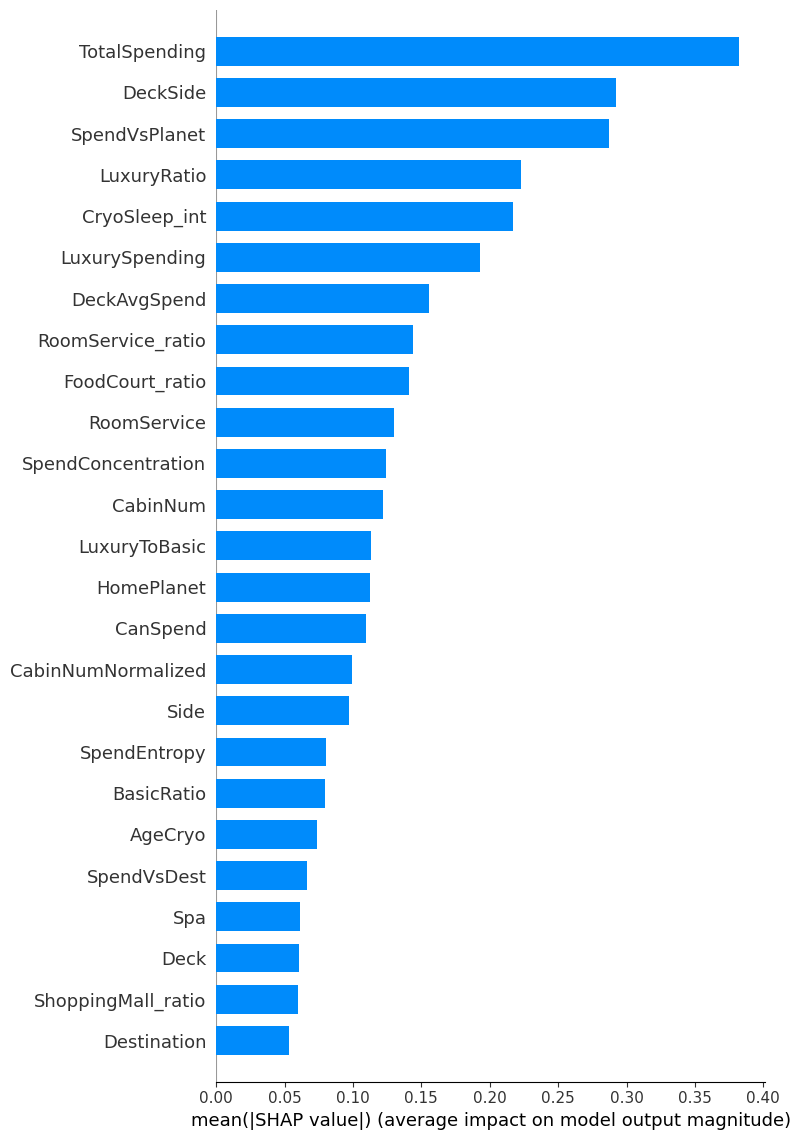


  Low importance features: ['SpendAbovePlanet', 'SameCabinAsGroup', 'VIP_LuxurySpend', 'ShoppingMall_WasNull', 'SameLastName', 'IsGroupPosition', 'FoodCourt_WasNull', 'HasShoppingMall', 'IsSolo', 'Side_WasNull', 'IsFamilyGroup', 'VIP_int', 'Deck_WasNull', 'HomePlanet_WasNull', 'VIP_WasNull', 'UniqueFamilyName', 'SpendAboveGroup', 'HasFoodCourt', 'HighSpendNonVIP', 'Spa_WasNull', 'WideAgeRange', 'Age_WasNull', 'GroupPlanetUnique', 'SameHomePlanet', 'HasSpa', 'CabinConflict', 'IsZeroSpender', 'ChildSpending', 'CryoSleep_Violated', 'ElderlySpending', 'IsElderly', 'LuxuryCryo']
  Pruned CV:   0.8102
  Original CV: 0.8115


In [254]:
lgbm_model.fit(X_train, y_train)
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_val)

feature_imp = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_train.columns
).sort_values(ascending=False)

print("  Top 20 features by SHAP:")
print(feature_imp.head(20))

shap.summary_plot(shap_values, X_val, plot_type='bar', max_display=25)

# Optional pruning
low_imp = feature_imp[feature_imp < 0.001].index.tolist()
if low_imp:
    print(f"\n  Low importance features: {low_imp}")
    pruned_scores = cross_val_score(
        LGBMClassifier(**best_lgbm),
        X_train.drop(columns=low_imp),
        y_train, cv=cv, scoring='accuracy'
    )
    print(f"  Pruned CV:   {pruned_scores.mean():.4f}")
    print(f"  Original CV: {study.best_value:.4f}")
    if pruned_scores.mean() >= study.best_value - 0.001:
        print("  ✅ Safe to drop low importance features")
        X_train = X_train.drop(columns=low_imp)
        X_val   = X_val.drop(columns=low_imp)
        X_test  = X_test.drop(columns=low_imp)



In [256]:
test_original    = pd.read_csv('/content/test_set_spaceship_titanic.csv')
sample_sub       = pd.read_csv('/content/sample_submission.csv')

# Retrain on full data
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

stack.fit(X_full, y_full)

# Predict
final_preds = stack.predict(X_test)

# Use sample_submission as template
submission = sample_sub.copy()
submission['Transported'] = final_preds.astype(bool)

# Sanity checks
assert submission.shape == sample_sub.shape
assert list(submission['PassengerId']) == list(sample_sub['PassengerId'])
assert submission['Transported'].dtype == bool
assert submission.isnull().sum().sum() == 0

print(f"Transported True:  {submission['Transported'].sum()}")
print(f"Transported False: {(~submission['Transported']).sum()}")
print(f"Transport rate:    {submission['Transported'].mean():.3f}")
print(submission.head(10))

submission.to_csv('submission.csv', index=False)
print("\n✅ Submission saved!")

Transported True:  2309
Transported False: 1968
Transport rate:    0.540
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
5     0027_01         True
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01         True

✅ Submission saved!
